In [1]:
# Required Libraries Import
# Data analysis, visualization aur machine learning ke libraries import kar rahe hai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Dataset Load Karna
# CSV file se energy consumption dataset read kar rahe hai
file_path = 'Office_Abbey.csv'
df = pd.read_csv('data/office_abbey.csv')
# Agar column ka naam Office_Abbey hai to usse meter_reading rename kar rahe hai
if 'Office_Abbey' in df.columns:
    df.rename(columns={'Office_Abbey': 'meter_reading'}, inplace=True)

print("Dataset Columns:", df.columns.tolist())
df.head()

Dataset Columns: ['timestamp', 'meter_reading']


,timestamp,meter_reading
0,2015-01-01 00:00:00,27.79
1,2015-01-01 01:00:00,27.66
2,2015-01-01 02:00:00,27.13
3,2015-01-01 03:00:00,27.34
4,2015-01-01 04:00:00,27.34


In [2]:
# Data Preprocessing
# Timestamp convert karna, sorting aur missing values fill karna
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)
# Missing values ko linear interpolation se fill kar rahe hai
df['meter_reading'] = df['meter_reading'].interpolate(method='linear')

# Feature Engineering
# Timestamp se naye features create kar rahe hai
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

print("Features engineered successfully.")

Features engineered successfully.


In [3]:
# eature Selection
# Model training ke liye input features aur target variable define kar rahe hai
features = ['hour', 'day_of_week', 'month', 'is_weekend']
X = df[features]
y = df['meter_reading']

# Train-Test Split
# Dataset ko training aur testing part me divide kar rahe hai
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model Training
# Random Forest Regression model train kar rahe hai
model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)


# Prediction aur Model Evaluation
# Model se prediction aur performance metrics calculate kar rahe hai
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Training Complete.\nRMSE: {rmse:.2f}\nR2 Score: {r2:.2f}")

Model Training Complete.
RMSE: 11.91
R2 Score: 0.62


In [4]:
# Optimization Strategy Logic
# Energy usage ke basis par optimization suggestions generate kar rahe hai
avg_val = df['meter_reading'].mean()

def suggest_optimization(row):
    usage = row['Actual_Usage']
    hour = row['hour']
    
    if (hour < 7 or hour > 20) and usage > (avg_val * 1.2):
        return "High Idle Load: Schedule Shutdown"
    elif usage > (avg_val * 1.5):
        return "Peak Load: Shift Operations"
    return "Optimal Usage"

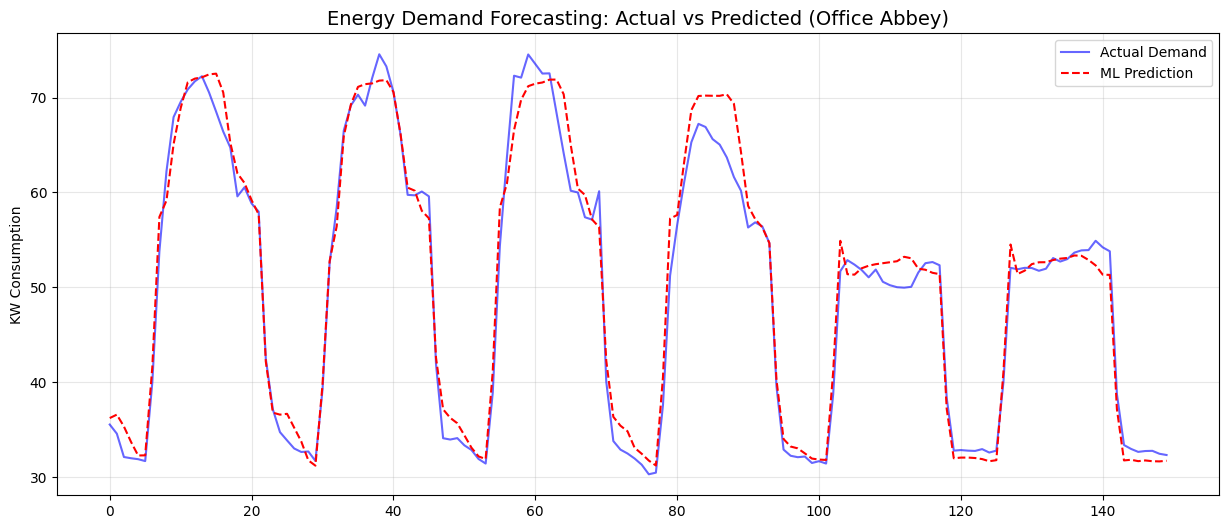


--- Final Optimization Report (First 10 Rows) ---
      hour  Actual_Usage       Strategy
7008     0         35.55  Optimal Usage
7009     1         34.59  Optimal Usage
7010     2         32.13  Optimal Usage
7011     3         32.00  Optimal Usage
7012     4         31.90  Optimal Usage
7013     5         31.70  Optimal Usage
7014     6         39.97  Optimal Usage
7015     7         53.79  Optimal Usage
7016     8         62.24  Optimal Usage
7017     9         67.94  Optimal Usage


In [5]:
# Result Dataframe Create Karna
# Actual aur predicted energy usage ko combine kar rahe hai
results = X_test.copy()
results['Actual_Usage'] = y_test.values
results['Predicted_Usage'] = y_pred

results['Strategy'] = results.apply(suggest_optimization, axis=1)

# Data Visualization
# Actual vs Predicted energy demand ka graph plot kar rahe hai
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:150], label='Actual Demand', color='blue', alpha=0.6)
plt.plot(y_pred[:150], label='ML Prediction', color='red', linestyle='--')
plt.title('Energy Demand Forecasting: Actual vs Predicted (Office Abbey)', fontsize=14)
plt.ylabel('KW Consumption')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Final Optimization Report
# First 10 rows ka optimization result print kar rahe hai
print("\n--- Final Optimization Report (First 10 Rows) ---")
print(results[['hour', 'Actual_Usage', 'Strategy']].head(10))